# Chapter 1: Research of Related Works

## Introduction

Transformers are extremely important to our electrical systems due to their ability to control and distribute power. Hence, it is paramount that we can accurately assess its current and future condition, allowing us to diagnose potential problems in transformers before they occur. Since oil temperature is a good proxy for transformer conditions, we want to use machine learning models to forecast future oil temperatures, giving us a good gaugue for the condition of the transformer.

## Related Works
In a paper by Huang Xuemin, Zhuang Xiaoliang, Tian Fangyuan, Niu Zheng, Chen Yujie, Zhou Qian, and Chao, Yuan (2025), they found that using a hybrid time series forecasting model combining ARIMA, LSTM, and XGBoost was able to outperform traditional machine learning models, as ARIMA was able to capture linear trending data, while LSTM and XGBoost were able to capture non-linear parts of the data. However, we are unable to use Autoregression Models like Arima because we cannot use past oil temperatures to predict for future oil temperature. Additionally, the model was only trained to predict for the next time point, while we need to create models that predict for more time points in the future. Hence, instead of implementing a similar hybrid model, we want to explore XGBoost and LSTM models by themselves as the success of the hybrid proves some efficacy at capturing the trends of the data, while also allowing us to see if the different prediction lengths might affect their performance. Furthermore, the model including ARIMA to capture linear patterns also shows that there might be value in considering linear regression which can also capture these linear relationships.





In a paper by Bai et al. (2018), they outlines the efficacy of time series models, LSTM, XGBoost ,ARIMA against Temporal Convolution Networks (TCN) across a range of sequence modelling tasks such as synthetic stress tests, language modelling and phonic music, tests generally created to benchmark TCN models showing that TCN models consistently outperform canonical recurrent architectures like LSTM and GRU across a variety of sequence modelling tasks. Hence our final model is a TCN model

## Addressing Limitations

One limitation mentioned by the papers is the computational intensity of these models in tuning and training. We will address this by using bayesian optimisation instead of just a grid search where appropriate for tuning, and we will limit the complexity of the models.

Another limitation or concern mentioned is the risk of overfitting. To combat this, we will add early stopping to our deep learning models, limit batch size and learning rate, and add dropout to our layers.

##Sources
Bai, Shaojie; Kolter, J. Zico; and Koltun, Vladlen. 2018. An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. arXiv preprint arXiv:1803.01271. (Related Work)

Huang, X.; Zhuang, X.; Tian, F.; Niu, Z.; Chen, Y.; Zhou, Q.; and Chao, Y. (2025). A Hybrid ARIMA-LSTM-XGBoost Model with Linear Regression Stacking for Transformer Oil Temperature Prediction. Energies 18(6), 1432. doi.org/10.3390/en18061432. (Related Work)

Toner, W., Darlow, L. 2024. An Analysis of Linear Time Series Forecasting Models. arXiv:2403.14587. doi.org/10.48550/arxiv.2403.14587.


# Chapter 2: Data Exploration, Feature Extraction and Visualization

## Importing Necessary Packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import math
from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
tf.random.set_seed(42)

import tensorflow as tf
import keras_tuner as kt
import math
from tcn import TCN
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model

## Reading In Dataset

We first import the 2 transformer datasets and merge them into a single dataframe

In [2]:
filepath = '../Model_and_Dataset/'
table1 = pd.read_csv(filepath + 'trans_1.csv')
#Create indicator column for transformer 1
table1['transformer'] = 1
table2 = pd.read_csv(filepath + 'trans_2.csv')
#Create indicator columns for transformer 2
table2['transformer'] = 2
data = pd.concat((table1,table2)).reset_index(drop=True)
data.head(10)

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,transformer
0,2018-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,1
1,2018-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999,1
2,2018-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000,1
3,2018-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000,1
4,2018-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001,1
5,2018-07-01 01:15:00,5.492,1.942,1.457,0.391,4.112,1.279,27.716999,1
6,2018-07-01 01:30:00,5.358,1.875,1.350,0.355,3.929,1.340,27.646000,1
7,2018-07-01 01:45:00,5.157,1.808,1.350,0.320,3.807,1.279,27.084000,1
8,2018-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001,1
9,2018-07-01 02:15:00,5.157,1.808,1.350,0.426,3.777,1.188,27.506001,1


## Data Exploration and Preparation

Next, we do some basic data exploration and preperation to ensure the data is in a usable state

We check if there is any missing data from any time point within the date range of the dataset

In [3]:
#Convert date to date_time
table1['date'] = pd.to_datetime(table1['date'])
table2['date'] = pd.to_datetime(table2['date'])
#Check for missing dates with difference
date_range = pd.date_range(table1['date'].min(),table1['date'].max(), freq='15T')
print(date_range.difference(table1['date']))
print(date_range.difference(table2['date']))

DatetimeIndex(['2020-02-29 00:00:00', '2020-02-29 00:15:00',
               '2020-02-29 00:30:00', '2020-02-29 00:45:00',
               '2020-02-29 01:00:00', '2020-02-29 01:15:00',
               '2020-02-29 01:30:00', '2020-02-29 01:45:00',
               '2020-02-29 02:00:00', '2020-02-29 02:15:00',
               '2020-02-29 02:30:00', '2020-02-29 02:45:00',
               '2020-02-29 03:00:00', '2020-02-29 03:15:00',
               '2020-02-29 03:30:00', '2020-02-29 03:45:00',
               '2020-02-29 04:00:00', '2020-02-29 04:15:00',
               '2020-02-29 04:30:00', '2020-02-29 04:45:00',
               '2020-02-29 05:00:00', '2020-02-29 05:15:00',
               '2020-02-29 05:30:00', '2020-02-29 05:45:00',
               '2020-02-29 06:00:00', '2020-02-29 06:15:00',
               '2020-02-29 06:30:00', '2020-02-29 06:45:00',
               '2020-02-29 07:00:00', '2020-02-29 07:15:00',
               '2020-02-29 07:30:00', '2020-02-29 07:45:00',
               '2020-02-

/tmp/ipython-input-2540104881.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  date_range = pd.date_range(table1['date'].min(),table1['date'].max(), freq='15T')


For both transformers, only February 29th is missing. Most likely, the way the data was recorded did not take into account the leap year, so no time point is actually missing

Next, we check that each column is in a usable numeric data type, and that there are no missing values

In [4]:
#Converting date to datetime object
data['date'] = pd.to_datetime(data['date'])
#checking presence of null values and data types
pd.concat((data.dtypes,data.isna().sum()), axis = 1)

,0,1
date,datetime64[ns],0
HUFL,float64,0
HULL,float64,0
MUFL,float64,0
MULL,float64,0
LUFL,float64,0
LULL,float64,0
OT,float64,0
transformer,int64,0


Then, we sort our dataframe by date and transformer to ensure that the dataframe is ascending chronologically and that it alternates between transformer 1 and 2, allowing us to easily manipulate and shift rows for future use

In [5]:
#sort data by ascending date and transformer
data = data.sort_values(['date','transformer'],ascending=[True,True]).reset_index(drop=True)
data.head(10)

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,transformer
0,2018-07-01 00:00:00,5.827000,2.009,1.599000,0.462,4.203,1.340,30.531000,1
1,2018-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999,2
2,2018-07-01 00:15:00,5.760000,2.076,1.492000,0.426,4.264,1.401,30.459999,1
3,2018-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000,2
4,2018-07-01 00:30:00,5.760000,1.942,1.492000,0.391,4.234,1.310,30.038000,1
5,2018-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002,2
6,2018-07-01 00:45:00,5.760000,1.942,1.492000,0.426,4.234,1.310,27.013000,1
7,2018-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001,2
8,2018-07-01 01:00:00,5.693000,2.076,1.492000,0.426,4.142,1.371,27.787001,1
9,2018-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001,2


Since each time point is 15 minutes, we need to shift our oil temperatures by 4, 96 and 672 time points back to get oil temperatures 1 hour, 1 day and 1 week in the future for each time point. However, since our dataset consists of 2 transformers that is now arranged in order, we shift by these time points multiplied by 2.

In [6]:
#Creating Future OT columns
data['OT_1'] = data['OT'].shift(-8)
data['OT_2'] = data['OT'].shift(-192)
data['OT_3'] = data['OT'].shift(-1344)
data.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,transformer,OT_1,OT_2,OT_3
0,2018-07-01 00:00:00,5.827000,2.009,1.599000,0.462,4.203,1.340,30.531000,1,27.787001,21.104000,31.093000
1,2018-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999,2,37.124001,25.917999,38.223000
2,2018-07-01 00:15:00,5.760000,2.076,1.492000,0.426,4.264,1.401,30.459999,1,27.716999,21.104000,30.601000
3,2018-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000,2,36.903999,25.917999,38.002998
4,2018-07-01 00:30:00,5.760000,1.942,1.492000,0.391,4.234,1.310,30.038000,1,27.646000,21.385000,31.093000


## Feature Visualisation

We plot the Oil temperature with respects to Time

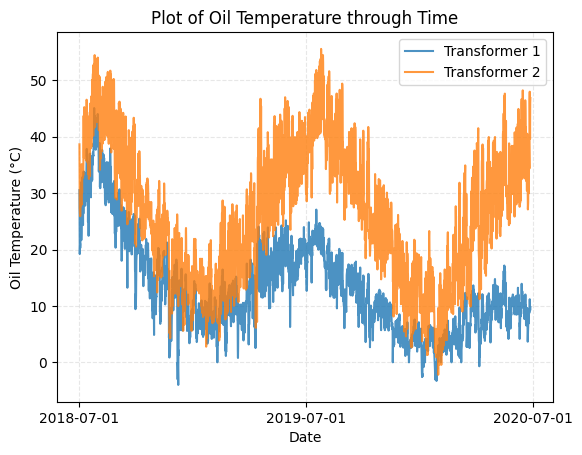

In [7]:
#Create line plots of oil temperature against time for each transformer
plt.plot(table1['date'][::24],table1['OT'][::24], label = 'Transformer 1', alpha=0.8)
plt.plot(table2['date'][::24],table2['OT'][::24], label= 'Transformer 2', alpha = 0.8)
plt.legend()
#Add titles, labels, legend and gridlines for clarity
plt.ylabel('Oil Temperature (°C)')
plt.xlabel('Date')
plt.xticks([datetime(2018,7,1),datetime(2019,7,1),datetime(2020,7,1)])
plt.title('Plot of Oil Temperature through Time')
plt.grid(linestyle = '--', alpha = 0.3)
plt.show()


We plot other features with respects to time

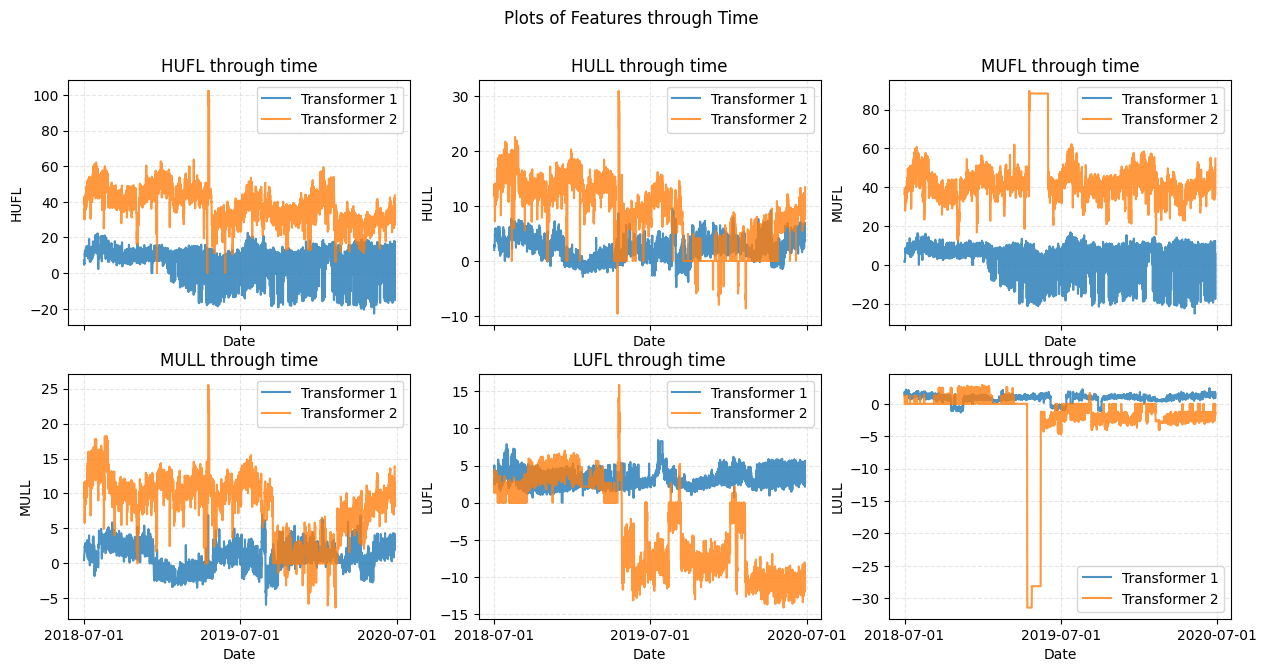

In [8]:
#Create Subplots
fig, axes = plt.subplots(2,3,figsize = (15, 7), sharex=True)
features = ['HUFL','HULL','MUFL','MULL','LUFL','LULL']
#loop through each axes and feature
for ax, feature in zip(axes.flatten(),features):
  #Create scatter plot of the feature against time for each transformer
  ax.plot(table1['date'][::24], table1[feature][::24], alpha = 0.8, label='Transformer 1')
  ax.plot(table2['date'][::24], table2[feature][::24], alpha = 0.8, label='Transformer 2')
  #Add titles, labels, legends and gridlines for clearer presentation
  ax.set_title(f'{feature} through time')
  ax.set_ylabel(feature)
  ax.set_xlabel('Date')
  ax.legend(loc='best')
  ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks([datetime(2018,7,1),datetime(2019,7,1),datetime(2020,7,1)])
plt.suptitle('Plots of Features through Time')
plt.show()

We plot the other features with respect to Oil Temperature

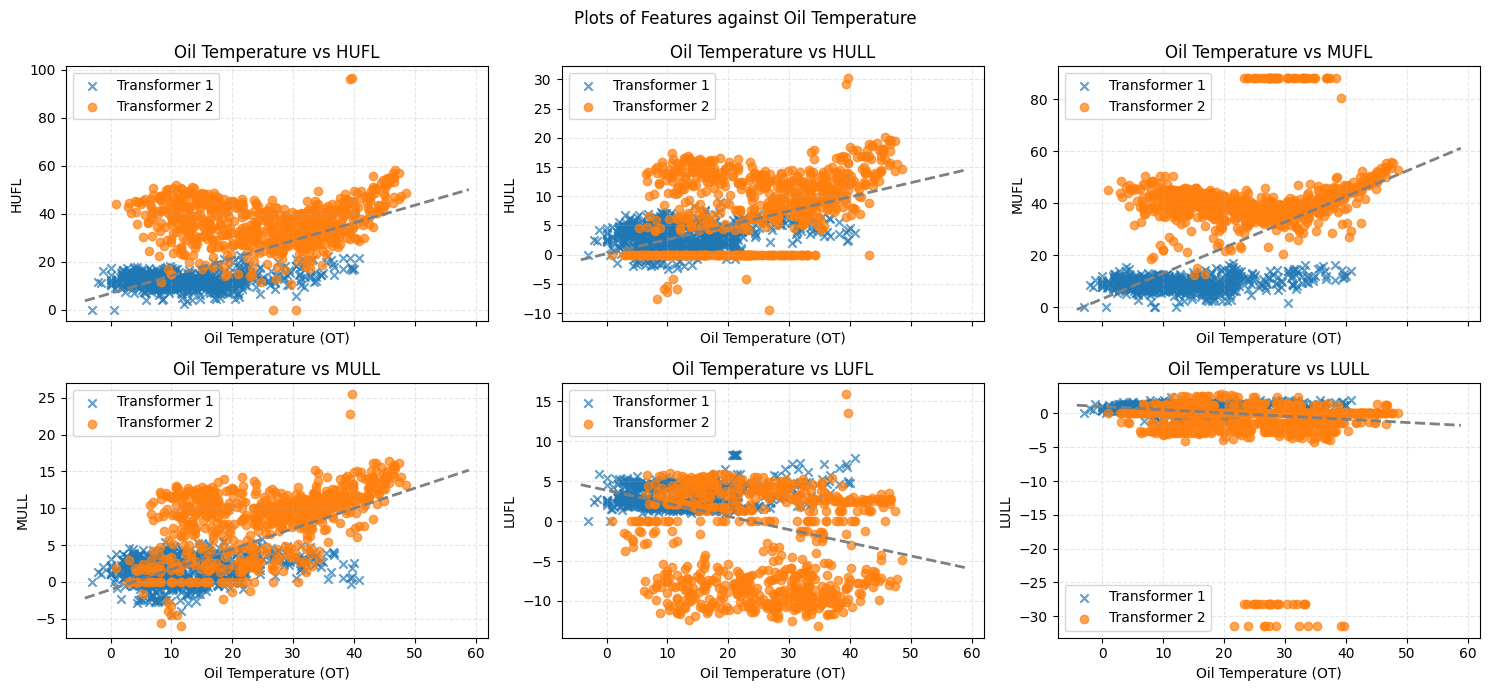

In [9]:
#Create Subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)  # Increased height for better spacing
features = ['HUFL','HULL','MUFL','MULL','LUFL','LULL']
#Loop through each axes and feature
for ax, feature in zip(axes.flatten(), features):
    #Create scatter plots for feature against OT for each transformer
    ax.scatter(table1['OT'][::96], table1[feature][::96], marker='x', alpha=0.7, label='Transformer 1')
    ax.scatter(table2['OT'][::96], table2[feature][::96], marker='o', alpha=0.7, label='Transformer 2')
    #Create a regression line for each plot
    sns.regplot(data=data, x='OT', y=feature,scatter=False, ci=None, line_kws={'linewidth': 2, 'linestyle': '--'}, robust=True, ax=ax, color = 'grey')
    #Add titles, labels, legends and gridlines for clearer presentation
    ax.set_title(f'Oil Temperature vs {feature}')
    ax.set_ylabel(feature)
    ax.set_xlabel('Oil Temperature (OT)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')
plt.suptitle('Plots of Features against Oil Temperature')
plt.tight_layout()
plt.show()


## Correlation Analysis

We do correlation analysis to further investigate each feature's correlation to oil temperature

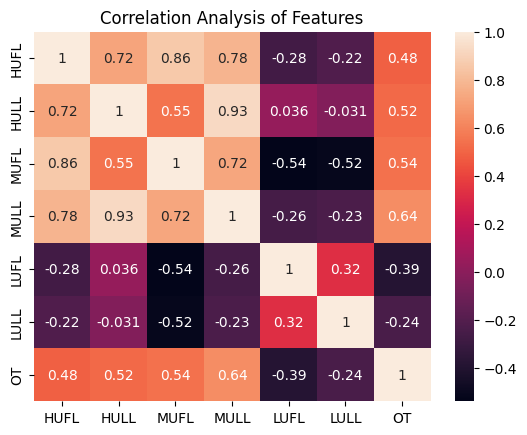

In [10]:
cor = data[['HUFL','HULL','MUFL','MULL','LUFL','LULL','OT']].corr()
sns.heatmap(cor,annot=True)
plt.title('Correlation Analysis of Features')
plt.show()
selected_features = ['HULL','MUFL','LULL','LUFL']

From the heatmap, we can see that HUFL has a high correlation with each HUFL and MUFL at 0.72 and 0.86 respectively, while MULL has a high correlation with HULL and MUFL at 0.93 and 0.72. Hence, we prune HUFL and MULL and select HULL, MUFL, LULL and LUFL as our input features for the rest of the project

## Data Preparation

We create time groups of 1 week of the dataset, then choose a random 20% of them as the test set. We then perform mean normalisation on the train and test set with respect with the training set (ie using mean, max and min of train set)

In [11]:
#Creating time point groups and splitting data into Train and Test set
np.random.seed(42)
#Splitting the data into time groups of 1 week
data['time_group'] = data.index// 1344
train_group = np.random.choice(range(0,102), size=int(102*0.8), replace=False)
test_group = np.setdiff1d(range(0,102),train_group)
train_data = data.loc[data['time_group'].isin(train_group)].copy()
test_data = data.loc[data['time_group'].isin(test_group)].copy()

#Mean normalisation
for column in train_data.columns[1:7]:
  mean, max, min = train_data[column].mean(), train_data[column].max(), train_data[column].min()
  train_data[column] = (train_data[column] - mean)/(max-min)
  test_data[column] = (test_data[column] - mean)/(max-min)

We then create datasets for each scenario with the selected mean normalised features and their respective future Oil temperature

In [12]:
#Create Dataset for first scenario
tf1 = train_data[selected_features+['OT_1','time_group']].copy()
tf1_test = test_data[selected_features+['OT_1','time_group']].copy()
tf1 = tf1.dropna()
tf1_test = tf1_test.dropna()
#Create Dataset for second scenario
tf2 = train_data[selected_features+['OT_2','time_group']].copy()
tf2_test = test_data[selected_features+['OT_2','time_group']].copy()
tf2 = tf2.dropna()
tf2_test = tf2_test.dropna()
#Create Dataset for third scenario
tf3 = train_data[selected_features+['OT_3','time_group']].copy()
tf3_test = test_data[selected_features+['OT_3','time_group']].copy()
tf3 = tf3.dropna()
tf3_test = tf3_test.dropna()

We create this function to create the lookback window

In [13]:
def time_window_vectorized(df, lookback=1, time_group_col='time_group'):
    import numpy as np

    # Separate features and group labels
    array = df.drop(columns=[time_group_col]).to_numpy()
    time_groups = df[time_group_col].to_numpy()
    jump = 2
    start_idx = (lookback - 1) * jump
    if start_idx >= len(array):
        return np.array([]), np.array([])

    n_samples = len(array) - start_idx

    # Create lookback index matrix
    indices = start_idx + np.arange(n_samples)[:, None]
    lookback_indices = indices - np.arange(lookback)[::-1] * jump

    #Check if entire lookback window is in the same time group
    group_at_indices = time_groups[lookback_indices]  # shape: (n_samples, lookback)
    same_group_mask = np.all(group_at_indices == group_at_indices[:, [0]], axis=1)

    # Filter indices
    lookback_indices = lookback_indices[same_group_mask]
    target_indices = indices[same_group_mask][:, 0]  # For y

    n_valid = len(lookback_indices)
    if n_valid == 0:
        return np.array([]), np.array([])

    # Extract features and targets
    X = array[lookback_indices, :-1].reshape(n_valid, lookback, -1)
    y = array[target_indices, -1]

    return X, y

# Chapter 3:

We will be implementing 4 models, Linear Regression, XGBoost, LSTM and TCN. For our lookback window N to tune, we will be genreally be using `range(0,11,1)` for scenario 1, `range(4,41,4)` for scenario 2, and `range(24,241,24)` for scenario 3. This is done to give predictions further in the future more time points to learn from without having to run a model for every N within the range.



## Linear Regression

For this problem, our baseline model will be Linear Regression. However, Linear Regression assumes that the error are independent and identically distributed, which might not hold for time series data. Despite this, Toner and Darlow (2024) found that Linear Regression performed well at time series forecasting despite its simplicity, even when pitted against more complicated models.

In [18]:
#Run if you're going to run any of the hyperparameter tuning code
kfld = KFold(n_splits=5)

### Hyperparameter Tuning

For Linear Regression, we will be tuning the lookback window N. The lookback window is implemented by adding the feature columns of every time point within the lookback window as an input to the model. For each scenario, we will be evaluating the models average RMSE on 5 folds for a range of N values.

In [19]:
#Scenario 1 (Don't need to run this)
lr_score_list_1 = []
#Loop over range of Ns
for n in range(1,11):
  #Create Lookback window for each N
  X, y = time_window_vectorized(tf1,lookback=n)
  X = X.reshape((len(X),len(selected_features)*n))
  scores = []

  # Loop over 5 folds
  for train_index, test_index in kfld.split(X):
    #Create train and test sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and Fit model
    model = LinearRegression()
    model.fit(X_train,y_train)

    #Predict y values and calulate RMSE
    y_pred = model.predict(X_test)
    scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

  #append average RMSE over folds to list
  lr_score_list_1.append(np.mean(scores))

#Display results in dataframe
lr_df_1 = pd.DataFrame({'N':range(1,11),'RMSE':lr_score_list_1})
lr_df_1.sort_values('RMSE',ascending = True)

,N,RMSE
0,1,11.095960
1,2,11.108462
2,3,11.121151
3,4,11.132673
4,5,11.144395
5,6,11.155373
6,7,11.166984
7,8,11.178541
8,9,11.189414
9,10,11.199609


#### Results
| N | RWSE |
|---|---|
| **1** |**11.095960**|
| 2 | 11.108462 |
| 3 | 11.121151 |
| 4 | 11.132673 |
| 5 | 11.144395 |
| 6 | 11.155373 |
| 7 | 11.166984 |
| 8 | 11.178541 |
| 9 | 11.189414 |
| 10 | 11.199609 |

Hence we use N=1 for scenario 1

In [ ]:
#Scenario 2 (Don't need to run this)
lr_score_list_2 = []
#Loop over range of Ns
for n in range(4,41,4):
  #Create Lookback window for each N
  X, y = time_window_vectorized(tf2,lookback=n)
  X = X.reshape((len(X),len(selected_features)*n))
  scores = []

  # Loop over 5 folds
  for train_index, test_index in kfld.split(X):
    #Create train and test sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and Fit model
    model = LinearRegression()
    model.fit(X_train,y_train)

    #Predict y values and calulate RMSE
    y_pred = model.predict(X_test)
    scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

  #append average RMSE over each fold to list
  lr_score_list_2.append(np.mean(scores))

#Display results in dataframe
lr_df_2 = pd.DataFrame({'N':range(4,41,4),'RMSE':lr_score_list_2})
lr_df_2.sort_values('RMSE',ascending = True)

,N,RMSE
0,4,11.206541
1,8,11.258989
2,12,11.314027
3,16,11.364929
4,20,11.412834
5,24,11.456431
6,28,11.498944
7,32,11.544251
8,36,11.586526
9,40,11.629640


#### Results
| N  | RNSE      |
|----|-----------|
| **4**  | **11.206541** |
| 8  | 11.258989 |
| 12 | 11.314027 |
| 16 | 11.364929 |
| 20 | 11.412834 |
| 24 | 11.456431 |
| 28 | 11.498944 |
| 32 | 11.544251 |
| 36 | 11.586526 |
| 40 | 11.629640 |

Hence we use N=4 for scenario 2

In [ ]:
#Scenario 3 (Don't need to run this)
lr_score_list_3 = []
#Loop over range of Ns
for n in range(24,241,24):
  #Create Lookback window for each N
  X, y = time_window_vectorized(tf3,lookback=n)
  X = X.reshape((len(X),len(selected_features)*n))
  scores = []

  # Loop over 5 folds
  for train_index, test_index in kfld.split(X):
    #Create train and test sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and Fit model
    model = LinearRegression()
    model.fit(X_train,y_train)
    #Predict y values and calulate RMSE
    y_pred = model.predict(X_test)
    scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

  #append average RMSE over each fold to list
  lr_score_list_3.append(np.mean(scores))

#Display results in dataframe
lr_df_3 = pd.DataFrame({'N':range(24,241,24),'RMSE':lr_score_list_3})
lr_df_3.sort_values('RMSE',ascending = True)

,N,RMSE
9,240,11.403894
8,216,11.412175
7,192,11.452592
6,168,11.559330
5,144,11.807197
4,120,11.821707
3,96,11.825618
2,72,11.900194
0,24,11.908969
1,48,12.079366


#### Results
| N    | RMSE       |
|------|------------|
| 24   | 11.908969  |
| 48   | 12.079366  |
| 72   | 11.900194  |
| 96   | 11.825618  |
| 120  | 11.821707  |
| 144  | 11.807197  |
| 168  | 11.559330  |
| 192  | 11.452592  |
| 216  | 11.412175  |
| **240**  | **11.403894**  |

Hence we use N=240 for scenario 3

### Training  Model

We then train the linear regression model with their respective lookback windows

In [ ]:
#Scenario 1 (Don't need to run this)
#Create Model
LR1T = LinearRegression()

#Create Lookback Window
X_train,y_train = time_window_vectorized(tf1,lookback=1)
X_train = X_train.reshape((len(X_train),len(selected_features)*1))

#Fit Model with Training Data
LR1T.fit(X_train,y_train)

np.float64(9.769859913440733)

In [ ]:
#Scenario 2 (Don't need to run this)
#Create Model
LR2T = LinearRegression()

#Create Lookback Window
X_train,y_train = time_window_vectorized(tf2,lookback=4)
X_train = X_train.reshape((len(X_train),len(selected_features)*4))

#Fit Model with Training Data
LR2T.fit(X_train,y_train)

np.float64(9.76095235349596)

In [ ]:
#Scenario 3 (Don't need to run this)
#Create Model
LR3T = LinearRegression()

#Create Lookback Window
X_train,y_train = time_window_vectorized(tf3,lookback=240)
X_train = X_train.reshape((len(X_train),len(selected_features)*240))

#Fit Model with Training Data
LR3T.fit(X_train,y_train)

np.float64(9.838427669171955)

## XGBoost

We will be implementing a XGBoost model due to its ability to build sequential trees, each learning from the previous tree, while maintaining speed and reducing chances of overfitting.

### Hyperparameter Tuning

For XGBoost, we will tune both the lookback window N and the hyperparameters that control the growth of the trees, the interactions between the trees, as well as the regularization parameters.

In [ ]:
# Scenario 1 (Don't need to run this)
xgb_score_1 = []
xgb_best_param_1 = []
#Loop over range of Ns
for n in range(1, 11, 1):
    print()
    print(f'Starting N: {n}')
    #Create lookback window
    X, y = time_window_vectorized(tf1,lookback=(n))
    X = X.reshape((len(X),len(selected_features)*(n)))
    #Create model
    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)
    #Range of parameters to test
    param_grid = {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5, 7],
        'reg_lambda': [0, 0.5, 1.0],
        'reg_alpha': [0, 0.5, 1.0]
    }
    #Randomly search through the range to obtain best parameters
    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid,
        n_iter=15,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X, y)
    best_params = search.best_params_
    print(best_params)
    xgb_best_param_1.append(best_params)
    scores = []
    tracker = 1
    #Loop over 5 folds
    for train_index, test_index in kfld.split(X):
        #Create train and test set
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        #Create model with best parameters
        model = XGBRegressor(**best_params)
        model.fit(X_train, y_train)
        #Predict and calculate RMSE
        y_pred = model.predict(X_test)
        scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        print(f'Fold {tracker} RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
        tracker += 1
    #Append average RMSE to list
    xgb_score_1.append(np.mean(scores))
    print(f'Average RMSE: {np.mean(scores)}')
#Present results in a dataframe
xgb_df_1 = pd.DataFrame({'N':range(1, 11, 1),'RMSE':xgb_score_1, 'Best Params':xgb_best_param_1})



Starting N: 1
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fold 1 RMSE: 17.656535162715603
Fold 2 RMSE: 12.236965852189016
Fold 3 RMSE: 11.298812328720603
Fold 4 RMSE: 9.001027266366867
Fold 5 RMSE: 9.949044003733633
Average RMSE: 12.028476922745146

Starting N: 2
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fold 1 RMSE: 17.831812540123032
Fold 2 RMSE: 12.991880586339843
Fold 3 RMSE: 10.563674021754855
Fold 4 RMSE: 8.941937392812944
Fold 5 RMSE: 9.640812870609164
Average RMSE: 11.994023482327966

Starting N: 3
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0, 'n_estimat

#### Results
| N | RMSE | Parameters |
|---|------|------------|
| 1 | 12.010117 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| **2** | **12.002105** | **{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}** |
| 3 | 12.082050 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| 4 | 12.142669 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| 5 | 12.131539 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| 6 | 12.137360 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| 7 | 12.151869 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| 8 | 12.134548 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}|
| 9 | 12.191695 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|10 | 12.200837 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |

Hence for scenario 1 we will use N = 2 and the parameters {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

In [ ]:
#Scenario 2 (Don't need to run this)
xgb_score_2 = []
xgb_best_param_2 = []
#Loop over range of Ns
for n in range(4, 41, 4):
    print()
    print(f'Starting N: {n}')
    #Create lookback window
    X, y = time_window_vectorized(tf2,lookback=(n))
    X = X.reshape((len(X),len(selected_features)*(n)))
    #Create model
    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)
    #Range of parameters to test
    param_grid = {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5, 7],
        'reg_lambda': [0, 0.5, 1.0],
        'reg_alpha': [0, 0.5, 1.0]
    }
    #Randomly search through the range to obtain best parameters
    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid,
        n_iter=15,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X, y)
    best_params = search.best_params_
    print(best_params)
    xgb_best_param_2.append(best_params)
    scores = []
    tracker = 1
    #Loop over 5 folds
    for train_index, test_index in kfld.split(X):
        #Create train and test set
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        #Create model with best parameters
        model = XGBRegressor(**best_params)
        model.fit(X_train, y_train)
        #Predict and calculate RMSE
        y_pred = model.predict(X_test)
        scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        print(f'Fold {tracker} RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
        tracker += 1
    #Append average RMSE to list
    xgb_score_2.append(np.mean(scores))
    print(f'Average RMSE: {np.mean(scores)}')
#Present results in a dataframe
xgb_df_2 = pd.DataFrame({'N':range(4, 41, 4),'RMSE':xgb_score_2, 'Best Params':xgb_best_param_2})



Starting N: 4
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fold 1 RMSE: 17.742818737423836
Fold 2 RMSE: 13.023527059814299
Fold 3 RMSE: 11.236581150611265
Fold 4 RMSE: 8.956223880277607
Fold 5 RMSE: 9.69012264481388
Average RMSE: 12.129854694588179

Starting N: 8
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fold 1 RMSE: 17.784439922376436
Fold 2 RMSE: 13.082192034137504
Fold 3 RMSE: 11.463392200765828
Fold 4 RMSE: 8.967196912255014
Fold 5 RMSE: 9.64560341612047
Average RMSE: 12.18856489713105

Starting N: 12
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estim

#### Results

| N | RMSE | Parameters |
|---|------|------------|
| 4 | 12.131653 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
| 8 | 12.189959 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|12 | 12.209903 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|16 | 12.158153 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|20 | 12.166744 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|24 | 12.104192 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|28 | 12.116032 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|32 | 12.110160 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|36 | 12.108601 | {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6} |
|**40** | **12.089588** | **{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}** |

Hence for scenario 2 we will use N = 40 and the parameters {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

In [ ]:
#Scenario 3 (Don't need to run this)
xgb_score_3 = []
xgb_best_param_3 = []
#Loop over range of Ns
for n in range(24, 241, 24):
    print()
    print(f'Starting N: {n}')
    #Create lookback window
    X, y = time_window_vectorized(tf3,lookback=(n))
    X = X.reshape((len(X),len(selected_features)*(n)))
    #Create model
    xgb = XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42)
    #Range of parameters to test
    param_grid = {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5, 7],
        'reg_lambda': [0, 0.5, 1.0],
        'reg_alpha': [0, 0.5, 1.0]
    }
    #Randomly search through the range to obtain best parameters
    search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_grid,
        n_iter=15,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X, y)
    best_params = search.best_params_
    print(best_params)
    xgb_best_param_3.append(best_params)
    tracker = 1
    scores = []
    #Loop over 5 folds
    for train_index, test_index in kfld.split(X):
        #Create train and test set
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        #Create model with best parameters
        model = XGBRegressor(**best_params)
        model.fit(X_train, y_train)
        #Predict and calculate RMSE
        y_pred = model.predict(X_test)
        scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        print(f'Fold {tracker} RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
        tracker += 1
    #Append average RMSE to list
    xgb_score_3.append(np.mean(scores))
    print(f'Average RMSE: {np.mean(scores)}')
#Present results in a dataframe
xgb_df_3 = pd.DataFrame({'N':range(24, 241, 24),'RMSE':xgb_score_3, 'Best Params':xgb_best_param_3})



Starting N: 24
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fold 1 RMSE: 16.918360330597267
Fold 2 RMSE: 11.883365003960208
Fold 3 RMSE: 11.273375349948191
Fold 4 RMSE: 8.541078561927264
Fold 5 RMSE: 9.435120520784091
Average RMSE: 11.610259953443403

Starting N: 48
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fold 1 RMSE: 17.055444609484795
Fold 2 RMSE: 12.016251683513817
Fold 3 RMSE: 11.593685939265267
Fold 4 RMSE: 8.336319767017411
Fold 5 RMSE: 9.072961494491944
Average RMSE: 11.614932698754647

Starting N: 72
Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Fold 1 RMSE: 17.021091971479372
Fold 2 RMSE: 12.423258550307576
Fold 3 RMSE: 10.205184851149582
Fold 4 RMSE: 7.982822440747329
Fold 5 RMSE: 7.813854166758558
Average RMSE: 11.089242396088483

Starting N: 192
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Fold 1 RMSE: 16.922473297456445
Fold 2 RMSE: 12.519571975750962
Fold 3 RMSE: 10.354086839995912
Fold 4 RMSE: 8.075718734849367
Fold 5 RMSE: 7.82007660535534
Average RMSE: 11.138385490681603

Starting N: 216
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Fold 1 RMSE: 17.02818286371127
Fold 2 RMSE: 12.33462330105383
Fold 3 RMSE: 10.471438569654557
Fold 4 RMSE: 8.044240547380882
Fold 5 RMSE: 7.760213914315855
Average RMSE: 11.127739839223278

Starting N: 240
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


#### Results


| N | RMSE | Parameters |
|---|------|------------|
|24 | 11.452126 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |
|48 | 11.244609 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |
|72 | 11.171935 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |
|96 | 11.115630 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |
|120| 11.118473 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |
|144| 11.136588 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
|**168**| **11.066674** | **{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}** |
|192| 11.104569 |{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |
|216| 11.122286 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}|
|240| 11.095412 | {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8} |

Hence for scenario 3 we will use N = 168 and the parameters {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

###Training Model

In [ ]:
#Scenario 1 (Don't need to run this)
#Create lookback window
n = 2
X_train, y_train = time_window_vectorized(tf1,lookback=(n))
X_train = X_train.reshape((len(X_train),len(selected_features)*(n)))
#Create model with best parameters
XGB1T = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
    subsample=0.8,
    reg_lambda=0.5,
    reg_alpha=0.5,
    n_estimators=200,
    min_child_weight=7,
    max_depth=5,
    learning_rate=0.01,
    colsample_bytree=0.6
)
#Fit model with training set
XGB1T.fit(X_train,y_train)

In [ ]:
#Scenario 2 (Don't need to run this)
#Create lookback window
n = 40
X_train, y_train = time_window_vectorized(tf2,lookback=(n))
X_train = X_train.reshape((len(X_train),len(selected_features)*(n)))
#Create model with best parameters
XGB2T = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
    subsample=0.8,
    reg_lambda=0.5,
    reg_alpha=0.5,
    n_estimators=200,
    min_child_weight=7,
    max_depth=5,
    learning_rate=0.01,
    colsample_bytree=0.6
)
#Fit model with training set
XGB2T.fit(X_train,y_train)

In [ ]:
#Scenario 3 (Don't need to run this)
#Create lookback window
n = 168
X_train, y_train = time_window_vectorized(tf3,lookback=(n))
X_train = X_train.reshape((len(X_train),len(selected_features)*(n)))
#Create model with best parameters
XGB3T = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
    subsample=0.6,
    reg_lambda=1.0,
    reg_alpha=0,
    n_estimators=200,
    min_child_weight=3,
    max_depth=9,
    learning_rate=0.01,
    colsample_bytree=0.8
)
#Fit model with training set
XGB3T.fit(X_train,y_train)

## LSTM

We will also be implementing a LSTM model due to its ability to capture long term dependencies in data while being resistant to the vanishing and exploding gradient problems.

### Hyperparameter Tuning

For LSTM, we will primarily be tuning the lookback window N due to runtime constraints. This is because the tuning of other hyperparamters such as the amount of LSTM cells would increase our runtime exponentially with respect to each N. Hence, we will be using a one layer LSTM model with 64 cells, as well as a learning rate of 0.0001 and batch size of 32 to prevent overfitting.

In [ ]:
#Scenario 1 (Don't need to run this)
lstm_scores_1 = []
#Loop over range of Ns
for n in range(2,12):
  print(f'####### N={n} #########')
  #Create lookback window
  X, y = time_window_vectorized(tf1,lookback=n)
  X = X.reshape((len(X),n,len(selected_features)))
  scores = []
  k = 1

  #Loop over 5 folds
  for train_index, test_index in kfld.split(X):
    print(f'##### {k}th fold #####')
    #Create Train and Test Set
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and fit model
    model = Sequential()
    model.add(InputLayer((n,len(selected_features))))
    model.add(LSTM(64))
    model.add(Dense(8,'relu'))
    model.add(Dense(1,'linear'))
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose = 1)

    #Predict and calculate RMSE
    y_pred = model.predict(X_test)
    scores.append(np.sqrt(mean_squared_error(y_pred,y_test)))
    k += 1

  #Append average RMSE to list
  lstm_scores_1.append(np.mean(scores))
  print(f'LSTM SCORES: {lstm_scores_1}')

#Present results in a dataframe
lstm_df_1 = pd.DataFrame({'N':range(2,12),'RMSE':lstm_scores_1})
lstm_df_1.sort_values('RMSE', ascending = True)


#### Results
| N | RMSE |
|---|---|
| 2 | **11.135924** |
| 3 | 11.500696 |
| 4 | 11.709298 |
| 5 | 11.958827 |
| 6 | 12.139633 |
| 7 | 12.644286 |
| 8 | 12.679013 |
| 9 | 12.753082 |
| 10 | 12.686586 |
| 11 | 12.939725 |

Hence we will be using N = 2 for scenario 1

In [ ]:
#Scenario 2 (Don't need to run this)
lstm_scores_2 = []
#Loop over range of Ns
for n in range(4,41,4):
  print(f'####### N={n} #########')
  #Create lookback window
  X, y = time_window_vectorized(tf2,lookback=n)
  X = X.reshape((len(X),n,len(selected_features)))
  scores = []
  k = 1

  #Loop over 5 folds
  for train_index, test_index in kfld.split(X):
    print(f'##### {k}th fold #####')
    #Create Train and Test Set
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and fit model
    model = Sequential()
    model.add(InputLayer((n,len(selected_features))))
    model.add(LSTM(64))
    model.add(Dense(8,'relu'))
    model.add(Dense(1,'linear'))
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose = 1)

    #Predict and calculate RMSE
    y_pred = model.predict(X_test)
    scores.append(np.sqrt(mean_squared_error(y_pred,y_test)))
    k += 1

  #Append average RMSE to list
  lstm_scores_2.append(np.mean(scores))
  print(f'LSTM SCORES: {lstm_scores_2}')

#Present results in a dataframe
lstm_df_2 = pd.DataFrame({'N':range(4,41,4),'RMSE':lstm_scores_2})
lstm_df_2.sort_values('RMSE',ascending=True)

#### Results

|   N |      RMSE |
|----:|----------:|
| **4** | **11.541924** |
|   8 | 12.545253 |
|  12 | 12.181205 |
|  16 | 12.873263 |
|  20 | 12.397405 |
|  24 | 12.986832 |
|  28 | 12.580119 |
|  32 | 12.261404 |
|  36 | 12.542965 |
|  40 | 12.687271 |

Hence we will be using N = 4 for scenario 2

In [ ]:
#Scenario 3 (Don't need to run this)
lstm_scores_3 = []
#Loop over range of Ns
for n in range(24,241,24):
  print(f'####### N={n} #########')
  #Create lookback window
  X, y = time_window_vectorized(tf3,lookback=n)
  X = X.reshape((len(X),n,len(selected_features)))
  scores = []
  k = 1

  #Loop over 5 folds
  for train_index, test_index in kfld.split(X):
    print(f'##### {k}th fold #####')
    #Create Train and Test Set
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Create and fit model
    model = Sequential()
    model.add(InputLayer((n,len(selected_features))))
    model.add(LSTM(64))
    model.add(Dense(8,'relu'))
    model.add(Dense(1,'linear'))
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose = 1)

    #Predict and calculate RMSE
    y_pred = model.predict(X_test)
    scores.append(np.sqrt(mean_squared_error(y_pred,y_test)))
    k+=1

  #Append average RMSE to list
  lstm_scores_3.append(np.mean(scores))
  print(f'LSTM SCORES: {lstm_scores_3}')

#Present results in a dataframe
lstm_df_3 = pd.DataFrame({'N':range(24,241,24),'RMSE':lstm_scores_3})
lstm_df_3.sort_values('RMSE', ascending = True)

#### Results
| N    | RMSE       |
|------|------------|
| 24   | 13.770711  |
| 48   | 12.957266  |
| 72   | 13.059214  |
| 96   | 12.361510  |
| 120  | 12.509347  |
| 144  | 11.629916  |
| 168  | 13.222785  |
| 192  | 12.687652  |
| 216  | 12.143395  |
| **240**  | **11.176240**  |

Hence we will be using N = 240 for scenario 3

### Training Model
For Model training of LSTM, we will be adding early stopping with a patience of 20 as well as a dropout of 0.2 to prevent overfitting

In [ ]:
#Run this if you are going to be running the lstm model training
early_stopping_1 = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=20,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

In [ ]:
#Scenario 1 (Don't need to run this)
#Create LSTM Model
N_1 = 2
LSTM1T = Sequential()
LSTM1T.add(InputLayer((N_1,len(selected_features))))
LSTM1T.add(LSTM(64, dropout = 0.2))
LSTM1T.add(Dense(8, activation='relu'))
LSTM1T.add(Dense(1, activation='linear'))

#Create lookback window
X_train, y_train = time_window_vectorized(tf1,lookback=N_1)
X_train = X_train.reshape((len(X_train),N_1,len(selected_features)))
LSTM1T.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

#Fit model with training set
history = LSTM1T.fit(X_train, y_train, epochs=300, validation_split=0.2, callbacks=[early_stopping_1], batch_size = 32)

In [ ]:
#Scenario 2 (Don't need to run this)
#Create LSTM Model
N_2 = 4
LSTM2T = Sequential()
LSTM2T.add(InputLayer((N_2,len(selected_features))))
LSTM2T.add(LSTM(64, dropout = 0.2))
LSTM2T.add(Dense(8,'relu'))
LSTM2T.add(Dense(1,'linear'))

#Create lookback window
X_train, y_train = time_window_vectorized(tf2,lookback=N_2)
X_train = X_train.reshape((len(X_train),N_2,len(selected_features)))
LSTM2T.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

#Fit model with training set
history = LSTM2T.fit(X_train, y_train, epochs=300,  validation_split=0.2, callbacks=[early_stopping_1], batch_size = 32)

In [ ]:
#Scenario 3 (Don't need to run this)
#Create LSTM Model
N_3 = 240
LSTM3T = Sequential()
LSTM3T.add(InputLayer((N_3,len(selected_features))))
LSTM3T.add(LSTM(64, dropout = 0.2))
LSTM3T.add(Dense(8,'relu'))
LSTM3T.add(Dense(1,'linear'))

#Create lookback window
X_train, y_train = time_window_vectorized(tf3,lookback=N_3)
X_train = X_train.reshape((len(X_train),N_3,len(selected_features)))
LSTM3T.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

#Fit model with training set
history = LSTM3T.fit(X_train, y_train, epochs=300, validation_split=0.2, callbacks=[early_stopping_1], batch_size = 32)


## TCN
We will also be implementing a TCN model because it employs causal dilated convolutions to capture long term dependencies in sequential data while respecting causality of time.

### Hyperparameter Tuning
For TCN, we require that its receptive field should cover all the input data supplied. As such, we will tune kernel size k, dilation base b, filters f, lookback window N and apply the relevant formula for number of convolutional layers L necessary.

In [ ]:
#Scenario 1 (Don't need to run this)
#Create model
def build_model(hp, n):
    #Our selected range of hyperparameters to test
    k = hp.Choice('kernel_size', [2, 3, 5])
    b = hp.Choice('dilation_base', [2, 3])
    f = hp.Choice('filters', [32, 64, 128])
    L = math.ceil(math.log(((n - 1)*(b - 1)/(k - 1)) + 1, b))
    model = Sequential([
        TCN(nb_filters=f, kernel_size=k, dilations=[b**i for i in range(L)],
            dropout_rate=0.2, return_sequences=False, input_shape=(n, len(selected_features))),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

overall_results = []
#Loop over range of Ns
for n in [2, 4, 6, 8]:
    print(f"\nRunning tuner search for lookback={n}")
    #Create lookback window
    X, y = time_window_vectorized(tf1, lookback=n)
    X = X.reshape((len(X), n, len(selected_features)))

    #Create Bayesian Optimizer
    tuner = kt.BayesianOptimization(
        lambda hp: build_model(hp, n),
        objective='val_loss',
        max_trials=20,
        directory='tcn1_tuning',
        project_name=f'tcn1_optimiser_lookback_{n}'
    )

    #Search for best set of hyperparameters
    tuner.search(X, y, validation_split=0.2, epochs=10)
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
    best_val_loss = best_trial.score

    #Append results to list
    overall_results.append({
        'lookback': n,
        'best_hp': best_hp.values,
        'val_loss': best_val_loss
    })
#Present results in a dataframe
results_df = pd.DataFrame(overall_results)
print(results_df)

#### Results
| N | Best Hyperparameters                                                                 | Validation Loss   |
|---------:|-------------------------------------------------------------------------|-----------:|
| 2        | `{'kernel_size': 5, 'dilation_base': 3, 'filters': 128}`                | 80.787231  |
| 4        | `{'kernel_size': 2, 'dilation_base': 3, 'filters': 32}`                | 75.346855  |
| **6**        | **`{'kernel_size': 2, 'dilation_base': 3, 'filters': 64}`**                | **52.528488**  |
| 8        | `{'kernel_size': 2, 'dilation_base': 3, 'filters': 32}`                | 55.811935  |

Hence we will be using N = 6, kernel size = 2, dilation base = 3 and filters = 64 for scenario 1.


In [ ]:
#Scenario 2 (Don't need to run this)
#Create model
def build_model(hp, n):
    #Our selected range of hyperparameters to test
    k = hp.Choice('kernel_size', [2, 3, 5])
    b = hp.Choice('dilation_base', [2, 3])
    f = hp.Choice('filters', [32, 64, 128])
    L = math.ceil(math.log(((n - 1)*(b - 1)/(k - 1)) + 1, b))
    model = Sequential([
        TCN(nb_filters=f, kernel_size=k, dilations=[b**i for i in range(L)],
            dropout_rate=0.2, return_sequences=False, input_shape=(n, len(selected_features))),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

overall_results = []
#Loop over range of Ns
for n in [10, 12, 14, 16]:
    print(f"\nRunning tuner search for lookback={n}")
    #Create lookback window
    X, y = time_window_vectorized(tf2, lookback=n)
    X = X.reshape((len(X), n, len(selected_features)))

    #Create Bayesian Optimizer
    tuner = kt.BayesianOptimization(
        lambda hp: build_model(hp, n),
        objective='val_loss',
        max_trials=20,
        directory='tcn2_tuning',
        project_name=f'tcn2_optimiser_lookback_{n}'
    )

    #Search for best set of hyperparameters
    tuner.search(X, y, validation_split=0.2, epochs=10)
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
    best_val_loss = best_trial.score

    #Append results to list
    overall_results.append({
        'lookback': n,
        'best_hp': best_hp.values,
        'val_loss': best_val_loss
    })

#Present results in a dataframe
results_df = pd.DataFrame(overall_results)
print(results_df)

#### Results
| N | Best Hyperparameters                                                                 | Validation Loss   |
|---------:|-------------------------------------------------------------------------|-----------:|
| 10       | `{'kernel_size': 2, 'dilation_base': 2, 'filters': 64}`                | 52.777996  |
| 12       | `{'kernel_size': 2, 'dilation_base': 2, 'filters': 64}`                | 53.331406  |
| **14**      | **`{'kernel_size': 2, 'dilation_base': 2, 'filters': 64}`**                | **52.178925**  |
| 16       | `{'kernel_size': 2, 'dilation_base': 2, 'filters': 64}`               | 54.200356 |

Hence we will be using N = 14, kernel size = 2, dilation base = 2 and filters = 64 for scenario 2.


In [ ]:
#Scenario 3 (Don't need to run this)
#Create model
def build_model(hp, n):
    #Our selected range of hyperparameters to test
    k = hp.Choice('kernel_size', [3, 5, 7])
    b = hp.Choice('dilation_base', [2, 3])
    f = 64
    L = math.ceil(math.log(((n - 1)*(b - 1)/(k - 1)) + 1, b))
    model = Sequential([
        TCN(nb_filters=f, kernel_size=k, dilations=[b**i for i in range(L)],
            dropout_rate=0.2, return_sequences=False, input_shape=(n, len(selected_features))),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

overall_results = []
#Loop over range of Ns
for n in [24,72, 132, 186, 240]:
    print(f"\nRunning tuner search for lookback={n}")
    #Create lookback window
    X, y = time_window_vectorized(tf3, lookback=n)
    X = X.reshape((len(X), n, len(selected_features)))

    #Create Bayesian Optimizer
    tuner = kt.BayesianOptimization(
        lambda hp: build_model(hp, n),
        objective='val_loss',
        max_trials=20,
        directory='tcn3_tuning',
        project_name=f'tcn3_optimiser_lookback_{n}'
        )

    #Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
        )

    #Reduce learning rate for more effective convergence
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
        )

    #Search for best set of hyperparameters
    tuner.search(X, y, validation_split=0.2, epochs=10, callbacks=[early_stopping, reduce_lr], verbose=1)
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
    best_model = tuner.get_best_models(1)[0]
    best_val_loss = best_trial.score
    final_lr = tf.keras.backend.get_value(best_model.optimizer.lr)
    epochs_run = len(best_trial.metrics.get_history('val_loss'))

    #Append results to list
    overall_results.append({
        'lookback': n,
        'best_hp': best_hp.values,
        'val_loss': best_val_loss,
        'final_lr': final_lr,
        'epochs_run': epochs_run
    })

#Present results in a dataframe
results_df = pd.DataFrame(overall_results)
print(results_df)

#### Results
| N | Best Hyperparameters                                                                 | Validation Loss   |
|---------:|-------------------------------------------------------------------------|-----------:|
| 24       | `{'kernel_size': 5, 'dilation_base': 2, 'filters': 64}`                | 63.634083  |
| 72       | `{'kernel_size': 5, 'dilation_base': 2, 'filters': 64}`                | 48.551112  |
| 132      | `{'kernel_size': 5, 'dilation_base': 2, 'filters': 64}`                | 58.605604  |
| 186       | `{'kernel_size': 5, 'dilation_base': 2, 'filters': 64}`               | 58.501049 |
| **240**       | **`{'kernel_size': 7, 'dilation_base': 3, 'filters': 64}`**               | **36.248817** |

Hence we will be using N = 240, kernel size = 7, dilation base = 3 and filters = 64 for scenario 3.


### Training Model

In [ ]:
#Run this if you are going to be running the tcn model training
early_stopping_2 = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
        )

reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-10,
        verbose=1
        )

In [ ]:
#Scenario 1 (Don't need to run this)
#Create TCN Model
N_1 = 6
TCN1T = Sequential()
TCN1T.add(InputLayer((N_1, len(selected_features))))
TCN1T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=1, padding = 'causal', activation='relu'))
TCN1T.add(BatchNormalization())
TCN1T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=3, padding = 'causal', activation='relu'))
TCN1T.add(BatchNormalization())
TCN1T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=9, padding = 'causal', activation='relu'))
TCN1T.add(BatchNormalization())
TCN1T.add(GlobalAveragePooling1D())
TCN1T.add(Dropout(0.2))
TCN1T.add(Dense(100, activation='relu'))
TCN1T.add(Dense(1, activation='linear'))

#Create lookback window
X_train, y_train = time_window_vectorized(tf1,lookback=N_1)
X_train = X_train.reshape((len(X_train), N_1, len(selected_features)))
TCN1T.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=1e-6), metrics=[RootMeanSquaredError()])

#Fit model with training set
history = TCN1T.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=64, callbacks=[early_stopping_2, reduce_lr], verbose=1)


Epoch 1/200
1351/1351 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 616.8543 - root_mean_squared_error: 24.8364 - val_loss: 378.1592 - val_root_mean_squared_error: 19.4463 - learning_rate: 1.0000e-06
Epoch 2/200
1351/1351 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 599.8593 - root_mean_squared_error: 24.4919 - val_loss: 363.2138 - val_root_mean_squared_error: 19.0582 - learning_rate: 1.0000e-06
Epoch 3/200
1351/1351 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 583.7647 - root_mean_squared_error: 24.1611 - val_loss: 349.6146 - val_root_mean_squared_error: 18.6980 - learning_rate: 1.0000e-06
Epoch 4/200
1351/1351 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 568.2064 - root_mean_squared_error: 23.8370 - val_loss: 336.4514 - val_root_mean_squared_error: 18.3426 - learning_rate: 1.0000e-06
Epoch 5/200
1351/1351 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 552.6418 - root_mean_squared_error: 23.5082 - val_loss: 322.6348 - val_root_mean_squared_error: 17.9620 - learning_rate: 1.0000e-06
Epoch 6/200
135

In [ ]:
#Scenario 2 (Don't need to run this)
#Create TCN Model
N_2 = 14
TCN2T = Sequential()
TCN2T.add(InputLayer((N_2, len(selected_features))))
TCN2T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=1, padding = 'causal', activation='relu'))
TCN2T.add(BatchNormalization())
TCN2T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=2, padding = 'causal', activation='relu'))
TCN2T.add(BatchNormalization())
TCN2T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=4, padding = 'causal', activation='relu'))
TCN2T.add(BatchNormalization())
TCN2T.add(Conv1D(filters=64, kernel_size=2, dilation_rate=8, padding = 'causal', activation='relu'))
TCN2T.add(BatchNormalization())
TCN2T.add(GlobalAveragePooling1D())
TCN2T.add(Dropout(0.2))
TCN2T.add(Dense(100, activation='relu'))
TCN2T.add(Dense(1, activation='linear'))

#Create lookback window
X_train, y_train = time_window_vectorized(tf2,lookback=N_2)
X_train = X_train.reshape((len(X_train), N_2, len(selected_features)))
TCN2T.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=1e-6), metrics=[RootMeanSquaredError()])

#Fit model with training set
history = TCN2T.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=64, callbacks=[early_stopping_2, reduce_lr], verbose=1)

Epoch 1/200
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - loss: 585.4833 - root_mean_squared_error: 24.1964 - val_loss: 353.3881 - val_root_mean_squared_error: 18.7986 - learning_rate: 1.0000e-06
Epoch 2/200
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - loss: 565.9047 - root_mean_squared_error: 23.7884 - val_loss: 324.8854 - val_root_mean_squared_error: 18.0246 - learning_rate: 1.0000e-06
Epoch 3/200
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - loss: 547.5637 - root_mean_squared_error: 23.3998 - val_loss: 302.2534 - val_root_mean_squared_error: 17.3854 - learning_rate: 1.0000e-06
Epoch 4/200
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - loss: 530.3425 - root_mean_squared_error: 23.0288 - val_loss: 282.7069 - val_root_mean_squared_error: 16.8139 - learning_rate: 1.0000e-06
Epoch 5/200
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - loss: 513.7331 - root_mean_squared_error: 22.6654 - val_loss: 265.8383 - val_root_mean_squared_error: 16.3045 - learning_rate: 1.0000e-06
Epoch 6/200
133

In [ ]:
#Scenario 3 (Don't need to run this)
#Create TCN Model
N_3 = 240
TCN3T = Sequential()
TCN3T.add(InputLayer((N_3, len(selected_features))))
TCN3T.add(Conv1D(filters=64, kernel_size=7, dilation_rate=1, padding = 'causal', activation='relu'))
TCN3T.add(BatchNormalization())
TCN3T.add(Conv1D(filters=64, kernel_size=7, dilation_rate=3, padding = 'causal', activation='relu'))
TCN3T.add(BatchNormalization())
TCN3T.add(Conv1D(filters=64, kernel_size=7, dilation_rate=9, padding = 'causal', activation='relu'))
TCN3T.add(BatchNormalization())
TCN3T.add(Conv1D(filters=64, kernel_size=7, dilation_rate=27, padding = 'causal', activation='relu'))
TCN3T.add(BatchNormalization())
TCN3T.add(GlobalAveragePooling1D())
TCN3T.add(Dropout(0.2))
TCN3T.add(Dense(100, activation='relu'))
TCN3T.add(Dense(1, activation='linear'))

#Create lookback window
X_train, y_train = time_window_vectorized(tf3,lookback=N_3)
X_train = X_train.reshape((len(X_train), N_3, len(selected_features)))
TCN3T.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=1e-6), metrics=[RootMeanSquaredError()])

#Fit model with training set
history = TCN3T.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=64, callbacks=[early_stopping, reduce_lr], verbose=1)

Epoch 1/200
877/877 ━━━━━━━━━━━━━━━━━━━━ 330s 370ms/step - loss: 576.8242 - root_mean_squared_error: 24.0164 - val_loss: 391.7281 - val_root_mean_squared_error: 19.7921 - learning_rate: 1.0000e-06
Epoch 2/200
877/877 ━━━━━━━━━━━━━━━━━━━━ 337s 384ms/step - loss: 558.3560 - root_mean_squared_error: 23.6287 - val_loss: 372.7563 - val_root_mean_squared_error: 19.3069 - learning_rate: 1.0000e-06
Epoch 3/200
877/877 ━━━━━━━━━━━━━━━━━━━━ 377s 378ms/step - loss: 540.5370 - root_mean_squared_error: 23.2486 - val_loss: 356.1085 - val_root_mean_squared_error: 18.8708 - learning_rate: 1.0000e-06
Epoch 4/200
877/877 ━━━━━━━━━━━━━━━━━━━━ 318s 363ms/step - loss: 523.7192 - root_mean_squared_error: 22.8841 - val_loss: 338.8592 - val_root_mean_squared_error: 18.4081 - learning_rate: 1.0000e-06
Epoch 5/200
877/877 ━━━━━━━━━━━━━━━━━━━━ 319s 360ms/step - loss: 508.3290 - root_mean_squared_error: 22.5454 - val_loss: 323.2101 - val_root_mean_squared_error: 17.9780 - learning_rate: 1.0000e-06
Epoch 6/200
877

# Chapter 4: Model Comparison and Evaluation

## Importing Models

In [14]:
LR1 = joblib.load(filepath + 'LR1.joblib')
LR2 = joblib.load(filepath + 'LR2.joblib')
LR3 = joblib.load(filepath + 'LR3.joblib')
XGB1 = joblib.load(filepath + "XGB1.joblib")
XGB2 = joblib.load(filepath + "XGB2.joblib")
XGB3 = joblib.load(filepath + "XGB3.joblib")
LSTM1 = load_model(filepath + 'LSTM1.keras')
LSTM2 = load_model(filepath + 'LSTM2.keras')
LSTM3 = load_model(filepath + 'LSTM3.keras')
TCN1 = load_model(filepath + 'TCN1.keras')
TCN2 = load_model(filepath + 'TCN2.keras')
TCN3 = load_model(filepath + 'TCN3.keras')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [16]:
def evaluate(model, data, N, flatten = True):
  X_test, y_test = time_window_vectorized(data,lookback = N)
  if flatten:
    X_test = X_test.reshape(len(X_test),len(selected_features)*N)
  y_pred = model.predict(X_test)
  return np.sqrt(mean_squared_error(y_test, y_pred))


## Scenario 1 Evaluation

In [ ]:
LR1_RMSE = evaluate(LR1,tf1_test,1)
XGB1_RMSE = evaluate(XGB1,tf1_test,2)
LSTM1_RMSE = evaluate(LSTM1,tf1_test,2,False)
TCN1_RMSE = evaluate(TCN1,tf1_test,6,False)
RMSE_1 = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost', 'LSTM', 'TCN'],
    'RMSE': [LR1_RMSE, XGB1_RMSE, LSTM1_RMSE, TCN1_RMSE]
})
RMSE_1

881/881 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
876/876 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,Model,RMSE
0,Linear Regression,9.769860
1,XGBoost,10.332882
2,LSTM,10.006650
3,TCN,10.458731


Results for Scenario 1:
| Model | RMSE|
|-------|-----|
|Linear Regression| 9.769860|
|XGBoost| 10.332882|
| LSTM | 10.006650 |
| TCN | 10.458731 |

## Scenario 2 Evaluation

In [ ]:
LR2_RMSE = evaluate(LR2,tf2_test,4)
XGB2_RMSE = evaluate(XGB2,tf2_test,40)
LSTM2_RMSE = evaluate(LSTM2,tf2_test,4,False)
TCN2_RMSE = evaluate(TCN2,tf2_test,14,False)
RMSE_2 = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost', 'LSTM', 'TCN'],
    'RMSE': [LR2_RMSE, XGB2_RMSE, LSTM2_RMSE, TCN2_RMSE]
})
RMSE_2

879/879 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
865/865 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step


,Model,RMSE
0,Linear Regression,9.760952
1,XGBoost,8.325358
2,LSTM,9.945482
3,TCN,9.900748


Results for Scenario 2:
|Model|RMSE|
|-|-|
|Linear Regression|  9.760952|
|XGBoost|8.325358|
|LSTM|9.945482|
|TCN|9.900748|


## Scenario 3 Evaluation

In [17]:
LR3_RMSE = evaluate(LR3,tf3_test,240)
XGB3_RMSE = evaluate(XGB3,tf3_test,168)
LSTM3_RMSE = evaluate(LSTM3,tf3_test,240,False)
TCN3_RMSE = evaluate(TCN3,tf3_test,240,False)
RMSE_3 = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost', 'LSTM', 'TCN'],
    'RMSE': [LR3_RMSE, XGB3_RMSE, LSTM3_RMSE, TCN3_RMSE]
})
RMSE_3

569/569 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step
569/569 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step


,Model,RMSE
0,Linear Regression,9.868775
1,XGBoost,11.242415
2,LSTM,10.152361
3,TCN,10.029252


Results for Scenario 3:
|Model|RSME|
|-|-|
|Linear Regression| 9.868775|
|XGBoost| 11.242415|
|LSTM| 10.152361|
|TCN| 10.235104|

## Conclusion

Suprisingly, Linear Regression performed the best despite it not being traditionally used for Time Series Forecasting. We suspect that due to the slicing of data into time point groups and selecting random ones for the test set, the temporal structure of our dataset broke, hurting XGBoost, LSTM and TCN while benefitting simpler models like linear regression

However, the ARIMA-LSTM-XGBoost hybrid model (Huang et al., 2025) significantly outperformed our models achieving an RMSE of 0.9954 with a similar dataset. This showcases the value of a hybrid model that can capture both linear and non-linear relationships, especially when dealing with complex time series data.